In [1]:
import pickle
import networkx as nx
import matplotlib.pyplot as plt
import sys
import os
from collections import defaultdict

# Fix import path for notebook environment
sys.path.append(os.path.abspath('..'))
import neural_net.nn as nn

def get_layered_pos(G, inputs, outputs):
    """
    Calculates a layout where nodes are organized in layers from left to right
    based on their topological distance from the input.
    """
    pos = {}
    layers = defaultdict(list)
    
    # 1. Assign Layers (X-coordinate)
    # Inputs are always layer 0
    node_layers = {n: 0 for n in inputs}
    
    # Calculate depth for other nodes (Longest path from input)
    # We use a simple relaxation; assuming DAG for visual clarity. 
    # If cycles exist, this limits depth to avoid infinite loops.
    for _ in range(len(G.nodes())): 
        updated = False
        for u, v in G.edges():
            if u in node_layers:
                current_depth = node_layers.get(v, -1)
                new_depth = node_layers[u] + 1
                if new_depth > current_depth:
                    node_layers[v] = new_depth
                    updated = True
        if not updated:
            break
            
    # Force outputs to be at the "last" layer
    max_layer = max(node_layers.values()) if node_layers else 0
    final_layer = max_layer + 1
    for n in outputs:
        node_layers[n] = final_layer
        
    # Group nodes by layer
    for node, layer in node_layers.items():
        layers[layer].append(node)
        
    # Handle disconnected nodes (assign to middle layer)
    middle_layer = final_layer // 2
    for node in G.nodes():
        if node not in node_layers:
            layers[middle_layer].append(node)
            node_layers[node] = middle_layer

    # 2. Assign Y-coordinates (Spread evenly within layer)
    # We center the layers vertically
    for layer_idx, nodes_in_layer in layers.items():
        # Sort nodes in layer to try and minimize crossings (heuristic: sort by ID)
        nodes_in_layer.sort()
        
        n_nodes = len(nodes_in_layer)
        # Calculate x: Normalize between -1 (input) and 1 (output)
        # Avoid division by zero if only 1 layer
        if final_layer > 0:
            x = (layer_idx / final_layer) * 2 - 1 
        else:
            x = 0
            
        for i, node in enumerate(nodes_in_layer):
            # Calculate y: Spread between -1 and 1
            if n_nodes > 1:
                y = (i / (n_nodes - 1)) * 2 - 1
            else:
                y = 0 
            
            # Special case: Center the layer if it has fewer nodes than the max layer
            # This makes it look more "pyramidal" or centered
            pos[node] = (x, y)
            
    return pos

def visualize_genome_layered(pkl_path, figsize=(14, 8)):
    # 1. Load Genome
    try:
        genome = nn.NetworkGenome.load_genome(pkl_path)
    except Exception as e:
        print(f"Error loading pickle: {e}")
        return

    # 2. Build Graph
    G = nx.DiGraph()
    inputs = [n.id for n in genome.input_neurons]
    outputs = [n.id for n in genome.output_neurons]
    hidden = [n.id for n in genome.neuron_gene]
    
    # Add Nodes
    G.add_nodes_from(inputs, type='input')
    G.add_nodes_from(outputs, type='output')
    G.add_nodes_from(hidden, type='hidden')
    
    # Add Edges
    active_edges = []
    disabled_edges = []
    
    for sg in genome.synapse_gene:
        if sg.is_on:
            G.add_edge(sg.outof.id, sg.into.id, weight=sg.weight)
            active_edges.append((sg.outof.id, sg.into.id))
        else:
            # We add disabled edges to the graph object to help layout calculation
            # (sometimes helpful to see "ghost" structure), but we style them differently
            G.add_edge(sg.outof.id, sg.into.id, weight=sg.weight)
            disabled_edges.append((sg.outof.id, sg.into.id))

    # 3. Calculate Layout
    pos = get_layered_pos(G, inputs, outputs)

    # 4. Draw
    plt.figure(figsize=figsize)
    plt.title(f"Gen {genome.id if hasattr(genome, 'id') else '?'} | Fitness: {genome.fitness:.1f} | Nodes: {len(G.nodes)}", fontsize=14)
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, nodelist=inputs, node_color='#a8dadc', node_size=600, label='Input', edgecolors='black')
    nx.draw_networkx_nodes(G, pos, nodelist=hidden, node_color='#f1faee', node_size=400, label='Hidden', edgecolors='gray')
    nx.draw_networkx_nodes(G, pos, nodelist=outputs, node_color='#e63946', node_size=600, label='Output', edgecolors='black')
    
    # Draw Labels
    nx.draw_networkx_labels(G, pos, font_size=8)
    
    # Draw Edges (Colored by weight)
    weights = [G[u][v]['weight'] for u, v in active_edges]
    max_w = max([abs(w) for w in weights]) if weights else 1
    
    # Color map: Red = Negative, Green = Positive
    edge_colors = ['#d62828' if w < 0 else '#2a9d8f' for w in weights]
    widths = [1 + (abs(w)/max_w)*2 for w in weights] # Scale width by magnitude
    
    # Draw Active
    nx.draw_networkx_edges(G, pos, edgelist=active_edges, edge_color=edge_colors, 
                           width=widths, alpha=0.7, arrowsize=15, connectionstyle="arc3,rad=0.1")
    
    # Draw Disabled (Very faint)
    nx.draw_networkx_edges(G, pos, edgelist=disabled_edges, edge_color='gray', 
                           style='dotted', width=1, alpha=0.1, arrows=False)

    # Custom Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#a8dadc', label='Input', markersize=10, markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#f1faee', label='Hidden', markersize=10, markeredgecolor='gray'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e63946', label='Output', markersize=10, markeredgecolor='black'),
        Line2D([0], [0], color='#2a9d8f', lw=2, label='Positive Weight'),
        Line2D([0], [0], color='#d62828', lw=2, label='Negative Weight'),
    ]
    plt.legend(handles=legend_elements, loc='upper left')
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()

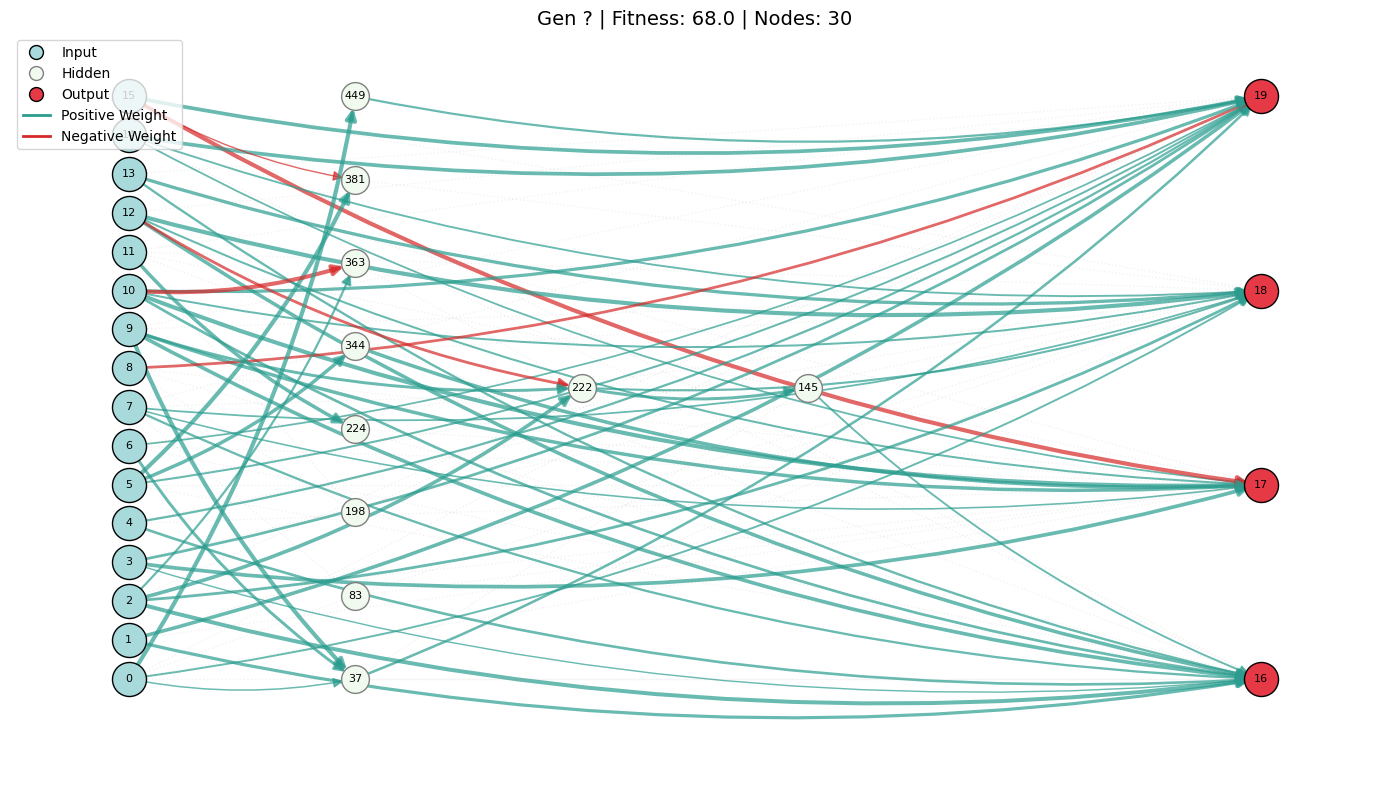

In [ ]:
# --- RUN CONFIGURATION ---
PKL_PATH = "../checkpoints/2025-12-18_19-37-49/gen_506_fit_68.pkl" 

if os.path.exists(PKL_PATH):
    visualize_genome_layered(PKL_PATH)
else:
    print("Please set PKL_PATH to a valid file.")

In [11]:
2**16

65536